# Compressed Sensing using Generative Models (Bora et al., 2017)
## A (didactic?) notebook in PyTorch

In [23]:
import yaml
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pl_modules import plVAE as VAE
from datasets import MNISTDataModule

In [2]:
with open('./lightning_logs/version_0/hparams.yaml', 'r') as file:
    params = yaml.safe_load(file)
    
pl_model = VAE(
    input_dim=params['input_dim'],
    latent_dim=params['latent_dim']
)

checkpoint = torch.load('./checkpoints/vae-best-epoch.ckpt')
pl_model.load_state_dict(checkpoint['state_dict'])

<All keys matched successfully>

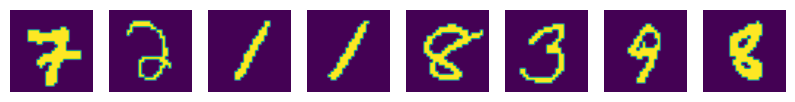

In [3]:
batch_size = 8
dataset = MNISTDataModule(batch_size)
val_data = dataset.val_dataloader()
batch = next(iter(val_data))

fig, axs = plt.subplots(1, batch_size, figsize=(10, 5))
for ax, img in zip(axs, batch[0]):
    ax.imshow(img[0])
    ax.axis('off')
plt.show()

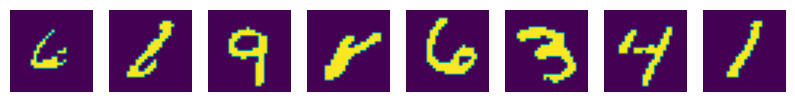

In [4]:
imgs = pl_model.model.sample(n_samples=batch_size)

fig, axs = plt.subplots(1, batch_size, figsize=(10, 5))
for ax, img in zip(axs, imgs):
    ax.imshow(img)
    ax.axis('off')
plt.show()

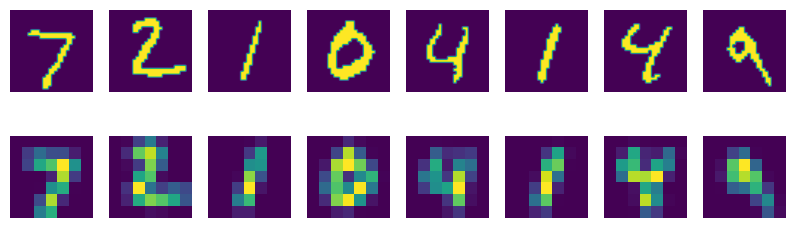

In [18]:
test_data = dataset.test_dataloader()
test_batch = next(iter(test_data))
lr_batch = dataset.hr2lr(test_batch[0])

fig, axs = plt.subplots(2, batch_size, figsize=(10, 3))
for ax, hr, lr in zip(axs.T, test_batch[0], lr_batch):
    ax[0].imshow(hr[0])
    ax[1].imshow(lr)
    ax[0].axis('off')
    ax[1].axis('off')
plt.show()

In [125]:
lr = 5e-4
n_it = 10000
l_reg = 1e-4
verbose = 500

In [120]:
z = torch.nn.Parameter(0.1 * torch.randn(batch_size, params['latent_dim']), requires_grad=True)
optimizer = torch.optim.Adam([z], lr=lr)

for it in range(n_it):
    x = pl_model.model.decode(z).view(-1, dataset.hr_size, dataset.hr_size)
    Ax = dataset.hr2lr(x)
    rec_loss = F.mse_loss(lr_batch, Ax)
    reg_loss = torch.sum(z**2, dim=-1).mean()
    loss = rec_loss + l_reg * reg_loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    
    if it == 0 or (it + 1) % verbose == 0:
        print("It {}: rec loss = {:.4f} - reg loss = {:.2f} - tot loss = {:.4f}".format(it+1, rec_loss, reg_loss, loss))

It 1: rec loss = 0.0202 - reg loss = 0.27 - tot loss = 0.0203
It 500: rec loss = 0.0137 - reg loss = 0.76 - tot loss = 0.0138
It 1000: rec loss = 0.0109 - reg loss = 1.23 - tot loss = 0.0110
It 1500: rec loss = 0.0090 - reg loss = 1.37 - tot loss = 0.0092
It 2000: rec loss = 0.0077 - reg loss = 1.55 - tot loss = 0.0079
It 2500: rec loss = 0.0065 - reg loss = 1.76 - tot loss = 0.0067
It 3000: rec loss = 0.0062 - reg loss = 1.90 - tot loss = 0.0064
It 3500: rec loss = 0.0060 - reg loss = 2.09 - tot loss = 0.0062
It 4000: rec loss = 0.0057 - reg loss = 2.24 - tot loss = 0.0059
It 4500: rec loss = 0.0055 - reg loss = 2.38 - tot loss = 0.0057
It 5000: rec loss = 0.0054 - reg loss = 2.53 - tot loss = 0.0057
It 5500: rec loss = 0.0054 - reg loss = 2.58 - tot loss = 0.0056
It 6000: rec loss = 0.0054 - reg loss = 2.59 - tot loss = 0.0056
It 6500: rec loss = 0.0054 - reg loss = 2.60 - tot loss = 0.0056
It 7000: rec loss = 0.0054 - reg loss = 2.61 - tot loss = 0.0056
It 7500: rec loss = 0.0054 - 

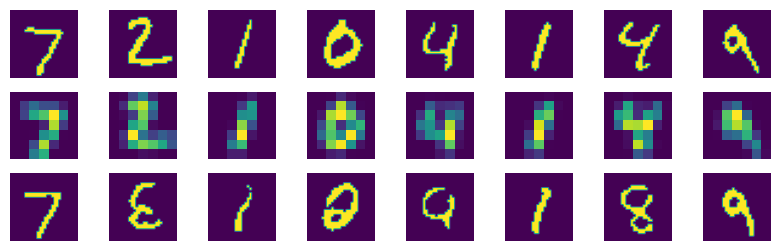

MSE: 0.0697


In [124]:
fig, axs = plt.subplots(3, batch_size, figsize=(10, 3))
for ax, hr_img, lr_img, rec in zip(axs.T, test_batch[0], lr_batch, x.detach()):
    ax[0].imshow(hr_img[0])
    ax[1].imshow(lr_img)
    ax[2].imshow((rec > 0.5).float())
    ax[0].axis('off')
    ax[1].axis('off')
    ax[2].axis('off')
plt.show()

print("MSE: {:.4f}".format(F.mse_loss(test_batch[0].squeeze(1), (x.detach() > 0.5).float()).item()))

In [126]:
z = torch.nn.Parameter(0.1 * torch.randn(batch_size, params['latent_dim']), requires_grad=True)
optimizer = torch.optim.Adam([z], lr=lr)

for it in range(n_it):
    x = pl_model.model.decode(z).view(-1, dataset.hr_size, dataset.hr_size)
    rec_loss = F.mse_loss(test_batch[0].squeeze(1), x)
    reg_loss = torch.sum(z**2, dim=-1).mean()
    loss = rec_loss + l_reg * reg_loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    
    if it == 0 or (it + 1) % verbose == 0:
        print("It {}: rec loss = {:.4f} - reg loss = {:.2f} - tot loss = {:.4f}".format(it+1, rec_loss, reg_loss, loss))

It 1: rec loss = 0.0982 - reg loss = 0.31 - tot loss = 0.0983
It 500: rec loss = 0.0752 - reg loss = 1.21 - tot loss = 0.0753
It 1000: rec loss = 0.0638 - reg loss = 2.40 - tot loss = 0.0641
It 1500: rec loss = 0.0546 - reg loss = 3.74 - tot loss = 0.0550
It 2000: rec loss = 0.0493 - reg loss = 4.65 - tot loss = 0.0498
It 2500: rec loss = 0.0472 - reg loss = 5.03 - tot loss = 0.0477
It 3000: rec loss = 0.0453 - reg loss = 5.59 - tot loss = 0.0458
It 3500: rec loss = 0.0446 - reg loss = 5.62 - tot loss = 0.0451
It 4000: rec loss = 0.0440 - reg loss = 5.64 - tot loss = 0.0446
It 4500: rec loss = 0.0439 - reg loss = 5.55 - tot loss = 0.0444
It 5000: rec loss = 0.0438 - reg loss = 5.55 - tot loss = 0.0444
It 5500: rec loss = 0.0438 - reg loss = 5.61 - tot loss = 0.0443
It 6000: rec loss = 0.0437 - reg loss = 5.68 - tot loss = 0.0443
It 6500: rec loss = 0.0437 - reg loss = 5.77 - tot loss = 0.0443
It 7000: rec loss = 0.0436 - reg loss = 5.85 - tot loss = 0.0442
It 7500: rec loss = 0.0436 - 

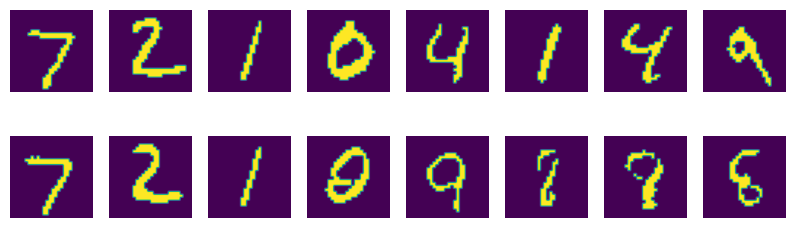

MSE: 0.0623


In [127]:
fig, axs = plt.subplots(2, batch_size, figsize=(10, 3))
for ax, hr_img, lr_img, rec in zip(axs.T, test_batch[0], lr_batch, x.detach()):
    ax[0].imshow(hr_img[0])
    ax[1].imshow((rec > 0.5).float())
    ax[0].axis('off')
    ax[1].axis('off')
plt.show()

print("MSE: {:.4f}".format(F.mse_loss(test_batch[0].squeeze(1), (x.detach() > 0.5).float()).item()))

In [128]:
z = torch.nn.Parameter(torch.randn(batch_size, params['latent_dim']), requires_grad=True)
optimizer = torch.optim.Adam([z], lr=lr)
y = dataset.hr2lr(imgs)

for it in range(n_it):
    x = pl_model.model.decode(z).view(-1, dataset.hr_size, dataset.hr_size)
    Ax = dataset.hr2lr(x)
    rec_loss = F.mse_loss(y, Ax)
    reg_loss = torch.sum(z**2, dim=-1).mean()
    loss = rec_loss + l_reg * reg_loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    
    if it == 0 or (it + 1) % verbose == 0:
        print("It {}: rec loss = {:.4f} - reg loss = {:.2f} - tot loss = {:.4f}".format(it+1, rec_loss, reg_loss, loss))

It 1: rec loss = 0.0361 - reg loss = 33.86 - tot loss = 0.0395
It 500: rec loss = 0.0293 - reg loss = 24.61 - tot loss = 0.0317
It 1000: rec loss = 0.0233 - reg loss = 18.08 - tot loss = 0.0251
It 1500: rec loss = 0.0201 - reg loss = 13.61 - tot loss = 0.0214
It 2000: rec loss = 0.0177 - reg loss = 10.50 - tot loss = 0.0187
It 2500: rec loss = 0.0132 - reg loss = 8.55 - tot loss = 0.0140
It 3000: rec loss = 0.0093 - reg loss = 7.19 - tot loss = 0.0100
It 3500: rec loss = 0.0073 - reg loss = 6.24 - tot loss = 0.0079
It 4000: rec loss = 0.0063 - reg loss = 5.70 - tot loss = 0.0069
It 4500: rec loss = 0.0058 - reg loss = 5.22 - tot loss = 0.0063
It 5000: rec loss = 0.0055 - reg loss = 5.05 - tot loss = 0.0060
It 5500: rec loss = 0.0050 - reg loss = 4.84 - tot loss = 0.0054
It 6000: rec loss = 0.0048 - reg loss = 4.71 - tot loss = 0.0053
It 6500: rec loss = 0.0047 - reg loss = 4.66 - tot loss = 0.0052
It 7000: rec loss = 0.0038 - reg loss = 4.80 - tot loss = 0.0043
It 7500: rec loss = 0.00

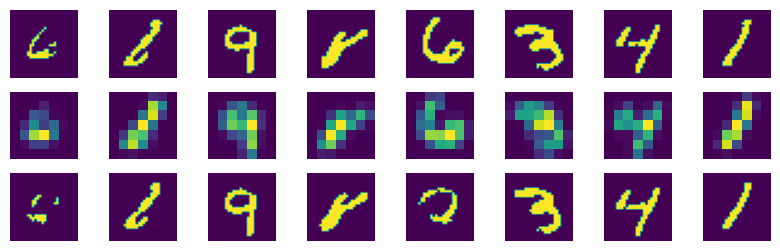

MSE: 0.0293


In [130]:
fig, axs = plt.subplots(3, batch_size, figsize=(10, 3))
for ax, hr_img, lr_img, rec in zip(axs.T, imgs, y, x.detach()):
    ax[0].imshow(hr_img)
    ax[1].imshow(lr_img)
    ax[2].imshow((rec > 0.5).float())
    ax[0].axis('off')
    ax[1].axis('off')
    ax[2].axis('off')
plt.show()

print("MSE: {:.4f}".format(F.mse_loss(imgs, (x.detach() > 0.5).float()).item()))